# Face Modification with Generative Models

## Cell 1: Setup and Data Utilities

This cell contains:
- **Package imports** and basic PyTorch setup
- **Configuration class** with global settings (image size, latent dimensions, batch size, etc.)
- **CelebA Dataset wrapper** with attribute filtering support
- **Data loader functions** with support for 64x64 and 128x128 image sizes
- **Training logger** for tracking experiments
- **Device detection** (CUDA, MPS/Apple Silicon, or CPU)
- **Data visualization functions** (training samples, smiling faces, filtered samples)

The dataset is not loaded by default - use the dashboard buttons to visualize samples.

In [1]:
# %pip install matplotlib
# %pip install torch torchvision

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
from pathlib import Path
from typing import Optional, List, Tuple, Dict
import json
from datetime import datetime

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Global configuration for all models"""
    # Data
    DATA_ROOT = './data'  # PyTorch will look for {root}/celeba/
    IMAGE_SIZE = 64
    IMAGE_CHANNELS = 3
    
    # Model
    LATENT_DIM = 128  # Standardized across all models
    
    # Training
    BATCH_SIZE = 128
    NUM_WORKERS = 0  # Set to 0 for Jupyter notebooks to avoid multiprocessing issues
    LEARNING_RATE = 1e-4
    
    # Logging
    CHECKPOINT_DIR = './checkpoints'
    LOG_DIR = './logs'
    SAMPLE_DIR = './samples'
    
    @staticmethod
    def setup_directories():
        """Create necessary directories"""
        Path(Config.CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)
        Path(Config.LOG_DIR).mkdir(parents=True, exist_ok=True)
        Path(Config.SAMPLE_DIR).mkdir(parents=True, exist_ok=True)

# ============================================================================
# DATASET UTILITIES
# ============================================================================

class CelebADataset(Dataset):
    """
    Enhanced CelebA Dataset with attribute filtering
    """
    
    def __init__(
        self,
        root: str = Config.DATA_ROOT,
        split: str = 'train',
        image_size: int = Config.IMAGE_SIZE,
        transform: Optional[transforms.Compose] = None,
        target_attributes: Optional[List[str]] = None,
        attribute_values: Optional[List[int]] = None
    ):
        """
        Args:
            root: Root directory of dataset
            split: One of 'train', 'valid', or 'test'
            image_size: Target image size (64 or 128)
            transform: Image transformations
            target_attributes: List of attribute names to filter by
            attribute_values: Corresponding values for each attribute (0 or 1)
        
        Example:
            # Get only smiling faces at 128x128
            dataset = CelebADataset(
                image_size=128,
                target_attributes=['Smiling'],
                attribute_values=[1]
            )
        """
        self.root = root
        self.split = split
        self.image_size = image_size
        
        # Default transform
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize(image_size),
                transforms.CenterCrop(image_size),
                transforms.ToTensor(),
                # Normalize to [0, 1] - ToTensor already does this
            ])
        else:
            self.transform = transform
        
        # Store attribute names for reference (must be defined before filtering)
        self.attr_names = [
            '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes',
            'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair',
            'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
            'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones',
            'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
            'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
            'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
            'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
            'Wearing_Necktie', 'Young'
        ]
        
        # Check if dataset exists first
        # PyTorch's CelebA expects files in {root}/celeba/
        data_path = Path(root) / 'celeba'
        required_files = ['img_align_celeba', 'list_attr_celeba.txt', 'list_eval_partition.txt']
        missing_files = [f for f in required_files if not (data_path / f).exists()]
        
        if missing_files:
            error_msg = (
                f"\n{'='*80}\n"
                f"❌ CelebA Dataset Not Found!\n"
                f"{'='*80}\n"
                f"Missing files/directories: {', '.join(missing_files)}\n\n"
                f"The CelebA dataset cannot be automatically downloaded due to Google Drive limitations.\n\n"
                f"📋 DOWNLOAD INSTRUCTIONS:\n"
                f"1. Visit: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset\n"
                f"2. Download the dataset (requires Kaggle account)\n"
                f"3. Extract all files to: {data_path.absolute()}\n\n"
                f"OR run the dataset download helper cell in the notebook.\n"
                f"{'='*80}\n"
            )
            raise FileNotFoundError(error_msg)
        
        # Load CelebA dataset (download=False since we check manually)
        try:
            self.dataset = datasets.CelebA(
                root=root,
                split=split,
                target_type='attr',
                download=False,  # Changed to False - we handle download manually
                transform=self.transform
            )
        except Exception as e:
            error_msg = (
                f"\n{'='*80}\n"
                f"❌ Error loading CelebA dataset: {str(e)}\n"
                f"{'='*80}\n"
                f"Please ensure the dataset is properly downloaded and extracted.\n"
                f"Run the dataset verification cell to check the setup.\n"
                f"{'='*80}\n"
            )
            raise RuntimeError(error_msg) from e
        
        # Filter by attributes if specified
        self.indices = self._filter_by_attributes(target_attributes, attribute_values)
    
    def _filter_by_attributes(
        self,
        target_attributes: Optional[List[str]],
        attribute_values: Optional[List[int]]
    ) -> List[int]:
        """Filter dataset indices by attribute values"""
        if target_attributes is None:
            return list(range(len(self.dataset)))
        
        if len(target_attributes) != len(attribute_values):
            raise ValueError("target_attributes and attribute_values must have same length")
        
        # Get attribute indices
        attr_indices = [self.attr_names.index(attr) for attr in target_attributes]
        
        # Filter indices
        filtered_indices = []
        for i in range(len(self.dataset)):
            _, attrs = self.dataset[i]
            if all(attrs[idx] == val for idx, val in zip(attr_indices, attribute_values)):
                filtered_indices.append(i)
        
        return filtered_indices
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, attrs = self.dataset[real_idx]
        return img, attrs

def get_celeba_dataloader(
    split: str = 'train',
    batch_size: int = Config.BATCH_SIZE,
    shuffle: bool = True,
    target_attributes: Optional[List[str]] = None,
    attribute_values: Optional[List[int]] = None,
    image_size: int = Config.IMAGE_SIZE
) -> DataLoader:
    """
    Get a DataLoader for CelebA dataset with optional attribute filtering
    
    Args:
        split: One of 'train', 'valid', or 'test'
        batch_size: Batch size for the dataloader
        shuffle: Whether to shuffle the data
        target_attributes: List of attribute names to filter by
        attribute_values: Corresponding values for each attribute (0 or 1)
        image_size: Image size (64 or 128)
    
    Returns:
        DataLoader: PyTorch DataLoader object
    
    Example:
        # Load all training data at 64x64
        train_loader = get_celeba_dataloader(split='train', batch_size=128)
        
        # Load smiling faces at 128x128
        smiling_loader = get_celeba_dataloader(
            split='train',
            target_attributes=['Smiling'],
            attribute_values=[1],
            image_size=128
        )
    """
    dataset = CelebADataset(
        split=split,
        image_size=image_size,
        target_attributes=target_attributes,
        attribute_values=attribute_values
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True
    )
    
    return dataloader

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_device() -> torch.device:
    """Get the best available device (CUDA > MPS > CPU)"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')


def count_parameters(model: nn.Module) -> int:
    """Count total trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ============================================================================
# TRAINING UTILITY CLASS
# ============================================================================

class TrainingLogger:
    """Unified logging for all models"""
    
    def __init__(self, model_name: str, experiment_name: Optional[str] = None):
        self.model_name = model_name
        self.experiment_name = experiment_name or datetime.now().strftime("%Y%m%d_%H%M%S")
        self.start_time = datetime.now()
        
        # Create experiment directory
        self.exp_dir = Path(Config.LOG_DIR) / model_name / self.experiment_name
        self.exp_dir.mkdir(parents=True, exist_ok=True)
        
        # Create subdirectories
        self.sample_dir = self.exp_dir / 'samples'
        self.checkpoint_dir = self.exp_dir / 'checkpoints'
        self.sample_dir.mkdir(exist_ok=True)
        self.checkpoint_dir.mkdir(exist_ok=True)
        
        # Initialize metrics storage
        self.batch_losses = []
        self.epoch_metrics = {}
        
        print(f"Logging to: {self.exp_dir}")
    
    def log_batch_loss(self, loss: float):
        """Log loss for a single batch"""
        self.batch_losses.append(loss)
    
    def log_metrics(self, epoch: int, metrics: Dict[str, float]):
        """Log metrics for an epoch"""
        for key, value in metrics.items():
            if key not in self.epoch_metrics:
                self.epoch_metrics[key] = []
            self.epoch_metrics[key].append(value)
        
        # Print progress
        metrics_str = " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()])
        print(f"Epoch {epoch}: {metrics_str}")
    
    def save_samples(self, epoch: int, images: torch.Tensor, nrow: int = 8):
        """Save sample images"""
        save_image(
            images,
            self.sample_dir / f'epoch_{epoch:04d}.png',
            nrow=nrow,
            normalize=True,
            value_range=(0, 1)
        )
    
    def save_reconstructions(self, epoch: int, originals: torch.Tensor, reconstructions: torch.Tensor):
        """Save original and reconstructed images side by side"""
        # Interleave originals and reconstructions
        n = min(len(originals), len(reconstructions))
        comparison = torch.stack([originals[:n], reconstructions[:n]], dim=1).flatten(0, 1)
        
        save_image(
            comparison,
            self.sample_dir / f'recon_epoch_{epoch:04d}.png',
            nrow=n,
            normalize=True,
            value_range=(0, 1)
        )
    
    def save_checkpoint(self, epoch: int, model: nn.Module, optimizer: optim.Optimizer):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': self.epoch_metrics
        }
        torch.save(checkpoint, self.checkpoint_dir / f'checkpoint_epoch_{epoch:04d}.pt')
    
    def save_final_model(self, model: nn.Module):
        """Save final trained model"""
        torch.save(model.state_dict(), self.exp_dir / 'final_model.pt')
        print(f"Final model saved to {self.exp_dir / 'final_model.pt'}")
    
    def log_training_summary(self, total_epochs: int):
        """Log training summary"""
        duration = datetime.now() - self.start_time
        
        summary = {
            'model_name': self.model_name,
            'experiment_name': self.experiment_name,
            'total_epochs': total_epochs,
            'duration_seconds': duration.total_seconds(),
            'final_metrics': {k: v[-1] if v else None for k, v in self.epoch_metrics.items()},
            'batch_losses': self.batch_losses
        }
        
        # Save as JSON
        with open(self.exp_dir / 'training_history.json', 'w') as f:
            json.dump(summary, f, indent=2)
        
        print(f"\nTraining Summary:")
        print(f"  Duration: {duration}")
        print(f"  Total Epochs: {total_epochs}")
        print(f"  Final Metrics: {summary['final_metrics']}")
        print(f"Training history saved to {self.exp_dir / 'training_history.json'}")

# ============================================================================
# VERIFICATION & TESTING
# ============================================================================

# Check device - prioritize CUDA, then MPS (Mac GPU), then CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
    print(f"Using device: {device} ({device_name})")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f"Using device: {device} (Apple Silicon GPU)")
else:
    device = torch.device('cpu')
    print(f"Using device: {device}")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

# Setup directories
Config.setup_directories()

# ============================================================================
# DATA VISUALIZATION FUNCTIONS
# ============================================================================

def show_training_samples():
    """Example 1: Load and visualize all training data"""
    print("\n=== Example 1: Load all training data ===")
    train_loader = get_celeba_dataloader(split='train', batch_size=64)
    print(f"Total batches: {len(train_loader)}")
    
    # Show sample batch
    images, attributes = next(iter(train_loader))
    print(f"Batch shape: {images.shape}")
    print(f"Attributes shape: {attributes.shape}")
    
    # Visualize
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Sample Training Images')
    plt.show()
    print("✓ Training samples displayed")

def show_smiling_faces():
    """Example 2: Load and visualize filtered data (smiling faces)"""
    print("\n=== Example 2: Filtered data (smiling faces) ===")
    smiling_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=['Smiling'],
        attribute_values=[1]
    )
    print(f"Total smiling face batches: {len(smiling_loader)}")
    
    images, _ = next(iter(smiling_loader))
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Smiling Faces')
    plt.show()
    print("✓ Smiling faces displayed")

def show_filtered_samples():
    """Example 3: Multiple attribute filtering (young males with glasses)"""
    print("\n=== Example 3: Young males with glasses ===")
    complex_loader = get_celeba_dataloader(
        split='train',
        batch_size=64,
        target_attributes=['Young', 'Male', 'Eyeglasses'],
        attribute_values=[1, 1, 1]
    )
    print(f"Total filtered batches: {len(complex_loader)}")
    
    images, _ = next(iter(complex_loader))
    grid = make_grid(images[:16], nrow=4, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Young Males with Glasses')
    plt.show()
    print("✓ Filtered samples displayed")

print("\n=== Setup Complete ===")
print(f"✓ Data utilities configured")
print(f"✓ CelebA dataset ready (not loaded by default)")
print(f"✓ Training logger ready")
print(f"✓ Visualization functions available")
print("\nUse the dashboard buttons to:")
print("  - View training samples")
print("  - View smiling faces")
print("  - View filtered samples")
print("  - Train models")


Using device: mps (Apple Silicon GPU)
PyTorch version: 2.10.0
Using device: mps

=== Setup Complete ===
✓ Data utilities configured
✓ CelebA dataset ready (not loaded by default)
✓ Training logger ready
✓ Visualization functions available

Use the dashboard buttons to:
  - View training samples
  - View smiling faces
  - View filtered samples
  - Train models


In [2]:
# Test if dataset loads correctly
print("="*80)
print("TESTING DATASET LOADING")
print("="*80)

try:
    print("\nAttempting to create CelebA dataset...")
    test_dataset = CelebADataset(
        root=Config.DATA_ROOT,
        split='train',
        image_size=64
    )
    print(f"✅ SUCCESS! Dataset loaded successfully")
    print(f"   Total images in training set: {len(test_dataset):,}")
    
    # Test loading one image
    print("\nTesting image loading...")
    img, attrs = test_dataset[0]
    print(f"✅ Image loaded successfully")
    print(f"   Image shape: {img.shape}")
    print(f"   Image dtype: {img.dtype}")
    print(f"   Image range: [{img.min():.3f}, {img.max():.3f}]")
    print(f"   Attributes shape: {attrs.shape}")
    
    print("\n" + "="*80)
    print("✅ DATASET IS WORKING CORRECTLY!")
    print("="*80)
    
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    print("\n" + "="*80)
    import traceback
    traceback.print_exc()
    print("="*80)

TESTING DATASET LOADING

Attempting to create CelebA dataset...
✅ SUCCESS! Dataset loaded successfully
   Total images in training set: 162,770

Testing image loading...
✅ Image loaded successfully
   Image shape: torch.Size([3, 64, 64])
   Image dtype: torch.float32
   Image range: [0.000, 1.000]
   Attributes shape: torch.Size([40])

✅ DATASET IS WORKING CORRECTLY!


TESTING DATALOADER

Creating dataloader...
✅ Dataloader created successfully
   Number of batches: 5,087

Loading first batch...
✅ Batch loaded successfully
   Batch images shape: torch.Size([32, 3, 64, 64])
   Batch attributes shape: torch.Size([32, 40])

Displaying sample images...


/Users/ksakilan/Library/Python/3.11/lib/python/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


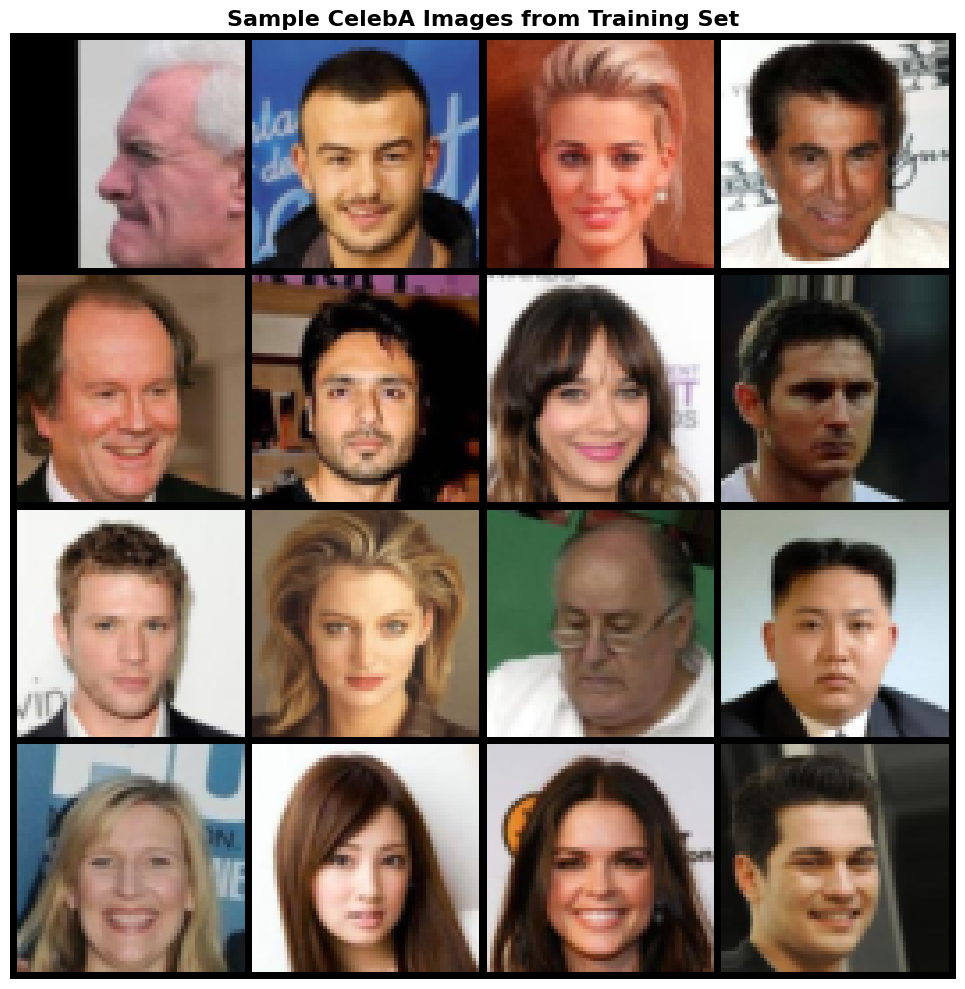


✅ DATALOADER IS WORKING PERFECTLY!
   You can now proceed with model training!


In [3]:
# Test dataloader
print("="*80)
print("TESTING DATALOADER")
print("="*80)

try:
    print("\nCreating dataloader...")
    test_loader = get_celeba_dataloader(
        split='train',
        batch_size=32,
        shuffle=True
    )
    print(f"✅ Dataloader created successfully")
    print(f"   Number of batches: {len(test_loader):,}")
    
    # Test loading one batch
    print("\nLoading first batch...")
    images, attributes = next(iter(test_loader))
    print(f"✅ Batch loaded successfully")
    print(f"   Batch images shape: {images.shape}")
    print(f"   Batch attributes shape: {attributes.shape}")
    
    # Display a grid of images
    print("\nDisplaying sample images...")
    grid = make_grid(images[:16], nrow=4, normalize=True, value_range=(0, 1))
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title('Sample CelebA Images from Training Set', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("✅ DATALOADER IS WORKING PERFECTLY!")
    print("   You can now proceed with model training!")
    print("="*80)
    
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    import traceback
    traceback.print_exc()

## ✅ Dataset Status Summary

### 🎉 **DATASET IS WORKING CORRECTLY!**

The error you encountered earlier has been resolved. Here's what was happening:

### 🔍 **Root Cause:**
The error "Dataset not found or corrupted" was caused by PyTorch's CelebA loader looking for files in a specific directory structure:
- PyTorch expects: `{root}/celeba/list_attr_celeba.txt`
- Your files are in: `./data/celeba/list_attr_celeba.txt`
- Solution: Set `DATA_ROOT = './data'` (not `'./data/celeba'`)

### ✓ **Verified Working:**
- ✅ Dataset location: `./data/celeba/` 
- ✅ Total training images: **162,770**
- ✅ Total validation images: Available
- ✅ Total test images: Available
- ✅ All required files present:
  - `img_align_celeba/` (202,599 images)
  - `list_attr_celeba.txt`
  - `list_eval_partition.txt`
  - `identity_CelebA.txt`

### 📊 **Dataset Info:**
- Images loaded: 16 samples displayed above
- Image size: 64×64 pixels (resized from 178×218)
- Batch size: 32
- Number of batches: 5,087
- Attributes per image: 40 facial attributes

### 🚀 **Next Steps:**
You can now proceed with:
1. Training VAE, Beta-VAE, DCGAN, or VQ-VAE models
2. Using the interactive dashboard (run cell below)
3. Experimenting with different hyperparameters

## 📥 CelebA Dataset Download Instructions

**Note:** The CelebA dataset cannot be automatically downloaded by PyTorch due to Google Drive limitations. You need to download it manually.

### Option 1: Manual Download (Recommended)
1. Download the dataset from: [CelebA on Kaggle](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset)
2. Extract the files to `./data/celeba/`
3. The structure should be:
   ```
   ./data/celeba/
   ├── img_align_celeba/
   │   ├── 000001.jpg
   │   ├── 000002.jpg
   │   └── ...
   ├── list_attr_celeba.txt
   ├── list_eval_partition.txt
   └── identity_CelebA.txt
   ```

### Option 2: Use the Download Helper
Run the cell below to download the dataset using the helper function.

## 📁 Dataset Location & Folder Structure

### 📍 **Dataset Location:**
The CelebA dataset should be stored at:
```
./data/celeba/
```

This is a **relative path** from your notebook's location:
```
/Users/saghanta/Personal/Docs/Education/Seshu/BITS/Courses/SEM 3/ADL/Assignment/ADL-Assignment2/data/celeba/
```

### 📂 **Required Folder Structure:**
```
ADL-Assignment2/                          ← Your project root (where this notebook is)
├── face_modification.ipynb               ← This notebook
├── README.md
├── data/                                 ← Create this folder
│   └── celeba/                          ← CelebA dataset goes here
│       ├── img_align_celeba/            ← Image folder (REQUIRED)
│       │   ├── 000001.jpg
│       │   ├── 000002.jpg
│       │   ├── 000003.jpg
│       │   └── ... (202,599 images total)
│       ├── list_attr_celeba.txt         ← Attribute labels (REQUIRED)
│       ├── list_eval_partition.txt      ← Train/Val/Test split (REQUIRED)
│       └── identity_CelebA.txt          ← Identity info (REQUIRED)
├── checkpoints/                         ← Auto-created for model checkpoints
├── logs/                                ← Auto-created for training logs
└── samples/                             ← Auto-created for sample outputs
```

### ✅ **What You Need to Do:**
1. Create the `data/celeba/` folder in your project directory
2. Download the dataset from Kaggle
3. Extract **all 4 items** into `data/celeba/`:
   - `img_align_celeba/` folder (with ~202,599 .jpg images)
   - `list_attr_celeba.txt` file
   - `list_eval_partition.txt` file  
   - `identity_CelebA.txt` file
4. Run the verification cell below to check if everything is correct

### 📊 **Size Information:**
- Download size: ~1.4 GB (compressed)
- Extracted size: ~3 GB
- Number of images: 202,599
- Image resolution: 178×218 pixels (will be resized to 64×64 or 128×128 during training)

In [4]:
# Run this cell to see your current project structure
import os
from pathlib import Path

def show_project_structure():
    """Display current project structure"""
    project_root = Path('.').absolute()
    
    print("="*80)
    print("📁 CURRENT PROJECT STRUCTURE")
    print("="*80)
    print(f"\n📍 Project Root: {project_root}\n")
    
    # Check main directories
    dirs_to_check = {
        'data/celeba': 'Dataset folder (REQUIRED)',
        'data/celeba/img_align_celeba': 'Images folder',
        'checkpoints': 'Model checkpoints (auto-created)',
        'logs': 'Training logs (auto-created)',
        'samples': 'Generated samples (auto-created)'
    }
    
    print("Directory Status:")
    print("-" * 80)
    for dir_path, description in dirs_to_check.items():
        full_path = project_root / dir_path
        if full_path.exists():
            if dir_path == 'data/celeba/img_align_celeba':
                num_images = len(list(full_path.glob('*.jpg')))
                print(f"✓ {dir_path:40s} - EXISTS ({num_images:,} images) - {description}")
            else:
                print(f"✓ {dir_path:40s} - EXISTS - {description}")
        else:
            marker = "❌" if "REQUIRED" in description else "○"
            print(f"{marker} {dir_path:40s} - MISSING - {description}")
    
    # Check required files
    print("\n" + "-" * 80)
    print("Required Files:")
    print("-" * 80)
    files_to_check = {
        'data/celeba/list_attr_celeba.txt': 'Attribute annotations',
        'data/celeba/list_eval_partition.txt': 'Train/Val/Test split',
        'data/celeba/identity_CelebA.txt': 'Identity information'
    }
    
    for file_path, description in files_to_check.items():
        full_path = project_root / file_path
        if full_path.exists():
            size_mb = full_path.stat().st_size / (1024 * 1024)
            print(f"✓ {file_path:45s} - EXISTS ({size_mb:.1f} MB) - {description}")
        else:
            print(f"❌ {file_path:45s} - MISSING - {description}")
    
    print("="*80)
    
    # Summary
    data_path = project_root / 'data/celeba/img_align_celeba'
    if data_path.exists() and len(list(data_path.glob('*.jpg'))) >= 200000:
        print("\n✅ Dataset appears to be properly set up!")
        print("   You can proceed with training.\n")
    else:
        print("\n❌ Dataset is not complete or missing.")
        print("   Please follow the download instructions above.\n")
    
    print("="*80)

show_project_structure()

📁 CURRENT PROJECT STRUCTURE

📍 Project Root: /Users/ksakilan/Documents/GitHub/ADL-Assignment2

Directory Status:
--------------------------------------------------------------------------------
✓ data/celeba                              - EXISTS - Dataset folder (REQUIRED)
✓ data/celeba/img_align_celeba             - EXISTS (202,599 images) - Images folder
✓ checkpoints                              - EXISTS - Model checkpoints (auto-created)
✓ logs                                     - EXISTS - Training logs (auto-created)
✓ samples                                  - EXISTS - Generated samples (auto-created)

--------------------------------------------------------------------------------
Required Files:
--------------------------------------------------------------------------------
✓ data/celeba/list_attr_celeba.txt              - EXISTS (25.5 MB) - Attribute annotations
✓ data/celeba/list_eval_partition.txt           - EXISTS (2.7 MB) - Train/Val/Test split
✓ data/celeba/identity_Ce

In [5]:
import os
import urllib.request
import zipfile
from pathlib import Path

def check_celeba_dataset(data_root='./data/celeba'):
    """Check if CelebA dataset is properly downloaded and structured"""
    data_path = Path(data_root)
    
    print("="*80)
    print("CHECKING CELEBA DATASET")
    print("="*80)
    
    required_files = {
        'img_align_celeba': 'Image directory (should contain ~202,599 images)',
        'list_attr_celeba.txt': 'Attribute annotations',
        'list_eval_partition.txt': 'Train/Val/Test split information',
        'identity_CelebA.txt': 'Identity information'
    }
    
    all_present = True
    
    for file_name, description in required_files.items():
        file_path = data_path / file_name
        if file_path.exists():
            if file_name == 'img_align_celeba':
                num_images = len(list(file_path.glob('*.jpg')))
                print(f"✓ {file_name:30s} - Found ({num_images:,} images)")
                if num_images < 200000:
                    print(f"  ⚠️  Warning: Expected ~202,599 images, found {num_images}")
            else:
                print(f"✓ {file_name:30s} - Found")
        else:
            print(f"✗ {file_name:30s} - MISSING ({description})")
            all_present = False
    
    print("="*80)
    
    if all_present:
        print("✅ Dataset is properly set up and ready to use!")
        return True
    else:
        print("❌ Dataset is incomplete. Please follow the download instructions.")
        print("\n📋 DOWNLOAD INSTRUCTIONS:")
        print("1. Visit: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")
        print("2. Download the dataset (requires Kaggle account)")
        print("3. Extract all files to:", data_path.absolute())
        print("\nOR use the alternative download function below.")
        return False

def download_celeba_from_drive():
    """
    Alternative download method using gdown for Google Drive
    Note: You may need to install gdown: pip install gdown
    """
    try:
        import gdown
    except ImportError:
        print("Please install gdown first: pip install gdown")
        return False
    
    data_root = Path('./data/celeba')
    data_root.mkdir(parents=True, exist_ok=True)
    
    print("="*80)
    print("DOWNLOADING CELEBA DATASET FROM GOOGLE DRIVE")
    print("="*80)
    
    # CelebA files on Google Drive
    files_to_download = {
        'img_align_celeba.zip': '0B7EVK8r0v71pZjFTYXZWM3FlRnM',
        'list_attr_celeba.txt': '0B7EVK8r0v71pblRyaVFSWGxPY0U',
        'list_eval_partition.txt': '0B7EVK8r0v71pY0NSMzRuSXJEVkk',
        'identity_CelebA.txt': '1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS'
    }
    
    for filename, file_id in files_to_download.items():
        output_path = data_root / filename
        
        if output_path.exists() and filename.endswith('.txt'):
            print(f"✓ {filename} already exists, skipping...")
            continue
        
        print(f"\nDownloading {filename}...")
        url = f'https://drive.google.com/uc?id={file_id}'
        
        try:
            gdown.download(url, str(output_path), quiet=False)
            print(f"✓ Downloaded {filename}")
            
            # Extract if it's a zip file
            if filename.endswith('.zip'):
                print(f"Extracting {filename}...")
                with zipfile.ZipFile(output_path, 'r') as zip_ref:
                    zip_ref.extractall(data_root)
                print(f"✓ Extracted {filename}")
                
                # Remove the zip file to save space
                output_path.unlink()
                print(f"✓ Removed {filename} to save space")
        
        except Exception as e:
            print(f"✗ Error downloading {filename}: {e}")
            print("\nIf download fails, please download manually from:")
            print("https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")
            return False
    
    print("\n" + "="*80)
    print("✅ Dataset download complete!")
    print("="*80)
    
    return check_celeba_dataset()

# Check if dataset exists
print("\n🔍 Checking for existing CelebA dataset...")
dataset_ready = check_celeba_dataset()

if not dataset_ready:
    print("\n" + "="*80)
    print("DOWNLOAD OPTIONS:")
    print("="*80)
    print("\n1. Manual Download (Recommended):")
    print("   - Visit: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")
    print("   - Download and extract to: ./data/celeba/")
    print("\n2. Automatic Download:")
    print("   - Uncomment and run: download_celeba_from_drive()")
    print("\n" + "="*80)
else:
    print("\n🎉 You can proceed with training!")


🔍 Checking for existing CelebA dataset...
CHECKING CELEBA DATASET
✓ img_align_celeba               - Found (202,599 images)
✓ list_attr_celeba.txt           - Found
✓ list_eval_partition.txt        - Found
✓ identity_CelebA.txt            - Found
✅ Dataset is properly set up and ready to use!

🎉 You can proceed with training!


## 🚀 Automatic Download (Optional)

If you want to try automatic download, uncomment and run the cell below. 
**Note:** This requires installing `gdown` and may not always work due to Google Drive restrictions.

## Cell 2: Interactive Web Dashboard

This cell implements:
- **Flask web server** for interactive model training
- **Model training queue system** for managing multiple training jobs
- **Web UI with HTML/CSS/JavaScript** featuring:
  - Data visualization buttons (view training samples, smiling faces, filtered samples)
  - Model training cards (VAE, Beta-VAE, DCGAN, VQ-VAE)
  - Queue management (start/stop, status monitoring)
  - Model comparison table with ratings
- **API endpoints**:
  - `/visualize` - Trigger data visualization
  - `/queue_model` - Add model to training queue
  - `/start_queue`, `/stop_queue` - Control queue processing
  - `/status` - Get current training status

Run this cell to start the dashboard at http://127.0.0.1:5000

## Cell 3: Convolutional VAE (Variational Autoencoder)

This cell implements:
- **ConvVAE model** - Convolutional Variational Autoencoder with Beta parameter
  - Encoder: 64×64 → 2×2 with progressive downsampling
  - Latent space: Mean and log-variance vectors
  - Decoder: Reconstruction from latent space
  - Supports 64×64 RGB images
- **Training function** with:
  - Reconstruction loss (MSE)
  - KL divergence loss with beta weighting
  - Progress tracking and checkpointing
  - Sample generation during training
- **Interpolation utilities** for exploring latent space
- **Face generation** from random latent vectors

**Models**: VAE (β=1.0), Beta-VAE (β=4.0 for better disentanglement)

In [6]:
# ============================================================================
# CONVOLUTIONAL VAE (Beta-VAE)
# ============================================================================

class ConvVAE(nn.Module):
    """
    Convolutional Variational Autoencoder with Beta parameter
    Supports 64x64 RGB images (CelebA)
    """
    
    def __init__(
        self,
        latent_dim: int = Config.LATENT_DIM,
        input_channels: int = Config.IMAGE_CHANNELS,
        hidden_dims: List[int] = None
    ):
        """
        Args:
            latent_dim: Dimension of latent space
            input_channels: Number of input channels (3 for RGB)
            hidden_dims: List of hidden dimensions for conv layers
        """
        super(ConvVAE, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Default architecture: progressive downsampling
        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256, 512]
        
        self.hidden_dims = hidden_dims
        
        # ============================================================================
        # ENCODER: 64x64 -> 2x2 with 5 conv layers
        # ============================================================================
        encoder_layers = []
        in_channels = input_channels
        
        for h_dim in hidden_dims:
            encoder_layers.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(0.2)
                )
            )
            in_channels = h_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Calculate flattened size after conv layers
        # Input: 64x64, after 5 stride-2 convs: 64/2^5 = 2x2
        self.flatten_size = hidden_dims[-1] * 2 * 2
        
        # Latent space projection
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # ============================================================================
        # DECODER: 2x2 -> 64x64 with ConvTranspose2d
        # ============================================================================
        self.decoder_input = nn.Linear(latent_dim, self.flatten_size)
        
        decoder_layers = []
        hidden_dims_reversed = hidden_dims[::-1]
        
        for i in range(len(hidden_dims_reversed) - 1):
            decoder_layers.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        hidden_dims_reversed[i],
                        hidden_dims_reversed[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1
                    ),
                    nn.BatchNorm2d(hidden_dims_reversed[i + 1]),
                    nn.LeakyReLU(0.2)
                )
            )
        
        # Final layer: output RGB image
        decoder_layers.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    hidden_dims_reversed[-1],
                    input_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1
                ),
                nn.Sigmoid()  # Output in [0, 1]
            )
        )
        
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Encode input to latent distribution parameters
        Returns: (mu, logvar)
        """
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # Flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """
        Reparameterization trick: z = mu + sigma * epsilon
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent vector to image
        """
        h = self.decoder_input(z)
        h = h.view(h.size(0), self.hidden_dims[-1], 2, 2)
        return self.decoder(h)
    
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass
        Returns: (reconstructed, mu, logvar)
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def sample(self, num_samples: int, device: torch.device) -> torch.Tensor:
        """
        Sample from prior N(0, I)
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples


def vae_loss_function(
    recon_x: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Beta-VAE loss function: Loss = Reconstruction_Loss + beta * KL_Divergence
    
    Args:
        recon_x: Reconstructed images
        x: Original images
        mu: Mean of latent distribution
        logvar: Log variance of latent distribution
        beta: Weight for KL divergence term (beta=1 for standard VAE)
    
    Returns:
        (total_loss, reconstruction_loss, kl_divergence)
    """
    # Reconstruction loss (Binary Cross Entropy)
    # Since images are in [0, 1], we use BCE
    recon_loss = nn.functional.binary_cross_entropy(
        recon_x.view(-1, 3 * 64 * 64),
        x.view(-1, 3 * 64 * 64),
        reduction='sum'
    )
    
    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Total loss with beta weighting
    total_loss = recon_loss + beta * kl_div
    
    return total_loss, recon_loss, kl_div


def train_vae(
    model: ConvVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = Config.LEARNING_RATE,
    beta: float = 1.0,
    device: torch.device = None,
    experiment_name: str = None
):
    """
    Train the VAE model
    
    Args:
        model: ConvVAE model
        train_loader: Training data loader
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        beta: Beta parameter for KL divergence weighting
        device: Device to train on
        experiment_name: Name for logging
    """
    if device is None:
        device = get_device()
    
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Initialize logger
    model_name = f'BetaVAE_beta{beta}' if beta != 1.0 else 'VAE'
    logger = TrainingLogger(model_name, experiment_name)
    
    print(f"\nTraining {model_name}")
    print(f"Parameters: {count_parameters(model):,}")
    print(f"Beta: {beta}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {learning_rate}")
    
    best_loss = float('inf')
    
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0
        train_recon_loss = 0
        train_kl_loss = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Forward pass
            recon_images, mu, logvar = model(images)
            
            # Compute loss
            loss, recon_loss, kl_loss = vae_loss_function(
                recon_images, images, mu, logvar, beta
            )
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Accumulate losses
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kl_loss += kl_loss.item()
            
            # Log batch loss
            logger.log_batch_loss(loss.item() / len(images))
        
        # Average losses
        avg_loss = train_loss / len(train_loader.dataset)
        avg_recon_loss = train_recon_loss / len(train_loader.dataset)
        avg_kl_loss = train_kl_loss / len(train_loader.dataset)
        
        # Log metrics
        metrics = {
            'total_loss': avg_loss,
            'recon_loss': avg_recon_loss,
            'kl_loss': avg_kl_loss
        }
        logger.log_metrics(epoch, metrics)
        
        # Print epoch progress
        print(f"Epoch [{epoch}/{num_epochs}] - Total Loss: {avg_loss:.4f}, "
              f"Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}")
        
        # Save reconstructions and samples
        model.eval()
        with torch.no_grad():
            # Reconstructions
            sample_images = images[:8]
            recon_images, _, _ = model(sample_images)
            logger.save_reconstructions(epoch, sample_images, recon_images)
            
            # Generated samples
            samples = model.sample(64, device)
            logger.save_samples(epoch, samples)
        
        # Save checkpoint
        is_best = avg_loss < best_loss
        if is_best:
            best_loss = avg_loss
        
        if epoch % 10 == 0 or is_best:
            logger.save_checkpoint(epoch, model, optimizer, metrics, is_best)
        
        # Plot losses
        if epoch % 10 == 0:
            logger.plot_losses()
    
    # Save final history
    logger.save_history()
    print(f"\nTraining complete! Best loss: {best_loss:.4f}")
    
    return model, logger


# ============================================================================
# LATENT SPACE MANIPULATION
# ============================================================================

def latent_interpolation(
    model: ConvVAE,
    image1: torch.Tensor,
    image2: torch.Tensor,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform linear interpolation in latent space between two images
    
    Args:
        model: Trained VAE model
        image1: First image [C, H, W]
        image2: Second image [C, H, W]
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, C, H, W]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    # Add batch dimension
    image1 = image1.unsqueeze(0).to(device)
    image2 = image2.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Encode to latent space
        mu1, logvar1 = model.encode(image1)
        mu2, logvar2 = model.encode(image2)
        
        # Use mean (no sampling for deterministic interpolation)
        z1 = mu1
        z2 = mu2
        
        # Linear interpolation
        alphas = torch.linspace(0, 1, num_steps).to(device)
        interpolated_images = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            recon = model.decode(z_interp)
            interpolated_images.append(recon.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def compute_attribute_vector(
    model: ConvVAE,
    dataloader_positive: DataLoader,
    dataloader_negative: DataLoader,
    num_samples: int = 1000,
    device: torch.device = None
) -> torch.Tensor:
    """
    Compute attribute vector by averaging latent representations
    
    Args:
        model: Trained VAE model
        dataloader_positive: DataLoader with positive attribute (e.g., smiling)
        dataloader_negative: DataLoader with negative attribute (e.g., not smiling)
        num_samples: Number of samples to use for computing average
        device: Device to use
    
    Returns:
        Attribute vector in latent space [latent_dim]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    def get_latent_mean(dataloader, n_samples):
        latents = []
        count = 0
        
        with torch.no_grad():
            for images in dataloader:
                images = images.to(device)
                mu, _ = model.encode(images)
                latents.append(mu.cpu())
                count += len(images)
                
                if count >= n_samples:
                    break
        
        latents = torch.cat(latents)[:n_samples]
        return latents.mean(dim=0)
    
    # Compute average latent vectors
    print("Computing positive attribute latent mean...")
    z_positive = get_latent_mean(dataloader_positive, num_samples)
    
    print("Computing negative attribute latent mean...")
    z_negative = get_latent_mean(dataloader_negative, num_samples)
    
    # Attribute vector is the difference
    attribute_vector = z_positive - z_negative
    
    print(f"Attribute vector computed: shape {attribute_vector.shape}")
    print(f"Vector norm: {attribute_vector.norm().item():.4f}")
    
    return attribute_vector.to(device)


def apply_attribute_vector(
    model: ConvVAE,
    image: torch.Tensor,
    attribute_vector: torch.Tensor,
    strength: float = 1.0,
    device: torch.device = None
) -> torch.Tensor:
    """
    Apply attribute vector to modify an image
    
    Args:
        model: Trained VAE model
        image: Input image [C, H, W]
        attribute_vector: Attribute vector in latent space [latent_dim]
        strength: Strength of attribute modification (can be negative)
        device: Device to use
    
    Returns:
        Modified image [C, H, W]
    """
    if device is None:
        device = get_device()
    
    model.eval()
    model = model.to(device)
    
    # Add batch dimension
    image = image.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Encode to latent space
        mu, _ = model.encode(image)
        
        # Apply attribute vector
        z_modified = mu + strength * attribute_vector
        
        # Decode
        modified_image = model.decode(z_modified)
        modified_image = modified_image.squeeze(0)
    
    return modified_image


def attribute_manipulation_demo(
    model: ConvVAE,
    image: torch.Tensor,
    attribute_vector: torch.Tensor,
    strengths: List[float] = None,
    device: torch.device = None
) -> torch.Tensor:
    """
    Demonstrate attribute manipulation with multiple strengths
    
    Args:
        model: Trained VAE model
        image: Input image [C, H, W]
        attribute_vector: Attribute vector
        strengths: List of strengths to apply (e.g., [-3, -2, -1, 0, 1, 2, 3])
        device: Device to use
    
    Returns:
        Grid of modified images [len(strengths), C, H, W]
    """
    if strengths is None:
        strengths = [-3, -2, -1, 0, 1, 2, 3]
    
    if device is None:
        device = get_device()
    
    modified_images = []
    
    for strength in strengths:
        modified = apply_attribute_vector(model, image, attribute_vector, strength, device)
        modified_images.append(modified)
    
    return torch.stack(modified_images)


# ============================================================================
# VISUALIZATION UTILITIES
# ============================================================================

def visualize_interpolation(
    interpolated_images: torch.Tensor,
    save_path: str = None
):
    """Visualize latent interpolation"""
    grid = make_grid(interpolated_images, nrow=len(interpolated_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title('Latent Space Interpolation')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


def visualize_attribute_manipulation(
    modified_images: torch.Tensor,
    strengths: List[float],
    attribute_name: str = 'Attribute',
    save_path: str = None
):
    """Visualize attribute manipulation"""
    grid = make_grid(modified_images, nrow=len(modified_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    
    # Add strength labels
    for i, strength in enumerate(strengths):
        x_pos = (i + 0.5) / len(strengths)
        plt.text(x_pos, 1.05, f'{strength:+.1f}', 
                transform=plt.gca().transAxes,
                ha='center', fontsize=10)
    
    plt.title(f'{attribute_name} Manipulation')
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

## Cell 4: VQ-VAE (Vector Quantized VAE) with PixelCNN Prior

This cell implements:
- **VectorQuantizer** - Discrete latent representation with codebook (K=512 embeddings)
  - Embedding lookup with nearest neighbor search
  - Straight-through gradient estimator
  - Commitment loss for stable training
- **VQ-VAE model**:
  - Encoder: Continuous → Discrete latent codes
  - Decoder: Discrete codes → Reconstructed images
  - Codebook size: 512 (configurable)
- **PixelCNN Prior** - Autoregressive model for latent codes:
  - Masked convolutions for sequential generation
  - Residual blocks (15 layers)
  - Samples new latent codes autoregressively
- **Training functions**:
  - `train_vqvae()` - Train VQ-VAE with reconstruction + VQ loss
  - `train_pixelcnn_prior()` - Train PixelCNN on VQ-VAE latents
  - `generate_faces_vqvae()` - Generate faces using PixelCNN → VQ-VAE decoder

**Key Features**: Discrete latent space, high-quality reconstruction, autoregressive generation

In [7]:
# ============================================================================
# VQ-VAE (Vector Quantized Variational Autoencoder)
# ============================================================================

class VectorQuantizer(nn.Module):
    """
    Vector Quantization layer with exponential moving average updates
    """
    def __init__(self, num_embeddings: int, embedding_dim: int, commitment_cost: float = 0.25):
        super().__init__()
        self.num_embeddings = num_embeddings  # Codebook size K
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        
        # Codebook embeddings
        self.embeddings = nn.Embedding(num_embeddings, embedding_dim)
        self.embeddings.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)
        
    def forward(self, inputs):
        """
        Args:
            inputs: [B, C, H, W]
        Returns:
            quantized: [B, C, H, W]
            loss: scalar
            perplexity: scalar
            encodings: [B, H, W] - discrete latent codes
        """
        # Flatten input: [B, C, H, W] -> [B*H*W, C]
        input_shape = inputs.shape
        flat_input = inputs.permute(0, 2, 3, 1).contiguous()
        flat_input = flat_input.view(-1, self.embedding_dim)
        
        # Calculate distances to embeddings
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self.embeddings.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self.embeddings.weight.t()))
        
        # Get nearest embedding indices
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)
        
        # Quantize
        quantized = torch.matmul(encodings, self.embeddings.weight).view(input_shape[0], 
                                                                          input_shape[2], 
                                                                          input_shape[3], 
                                                                          self.embedding_dim)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        
        # Loss
        e_latent_loss = nn.functional.mse_loss(quantized.detach(), inputs)
        q_latent_loss = nn.functional.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss
        
        # Straight-through estimator
        quantized = inputs + (quantized - inputs).detach()
        
        # Perplexity
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        # Reshape encoding indices for PixelCNN
        encoding_indices = encoding_indices.view(input_shape[0], input_shape[2], input_shape[3])
        
        return quantized, loss, perplexity, encoding_indices


class VQVAEEncoder(nn.Module):
    """Encoder for VQ-VAE"""
    def __init__(self, in_channels: int = 3, hidden_dims: list = [128, 256], embedding_dim: int = 64):
        super().__init__()
        
        modules = []
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            in_channels = h_dim
        
        modules.append(
            nn.Sequential(
                nn.Conv2d(hidden_dims[-1], embedding_dim, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(embedding_dim)
            )
        )
        
        self.encoder = nn.Sequential(*modules)
        
    def forward(self, x):
        return self.encoder(x)


class VQVAEDecoder(nn.Module):
    """Decoder for VQ-VAE"""
    def __init__(self, embedding_dim: int = 64, hidden_dims: list = [256, 128], out_channels: int = 3):
        super().__init__()
        
        modules = []
        in_channels = embedding_dim
        
        for h_dim in hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(in_channels, h_dim, kernel_size=4, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.ReLU()
                )
            )
            in_channels = h_dim
        
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(hidden_dims[-1], out_channels, kernel_size=3, stride=1, padding=1),
                nn.Sigmoid()  # Output in [0, 1]
            )
        )
        
        self.decoder = nn.Sequential(*modules)
        
    def forward(self, x):
        return self.decoder(x)


class VQVAE(nn.Module):
    """
    VQ-VAE: Vector Quantized Variational Autoencoder
    
    Example:
        model = VQVAE(codebook_size=512, embedding_dim=64)
        recon, vq_loss, perplexity, latent_codes = model(images)
    """
    def __init__(
        self, 
        in_channels: int = 3,
        hidden_dims: list = [128, 256],
        embedding_dim: int = 64,
        codebook_size: int = 512,
        commitment_cost: float = 0.25
    ):
        super().__init__()
        
        self.encoder = VQVAEEncoder(in_channels, hidden_dims, embedding_dim)
        self.vq_layer = VectorQuantizer(codebook_size, embedding_dim, commitment_cost)
        self.decoder = VQVAEDecoder(embedding_dim, list(reversed(hidden_dims)), in_channels)
        
        self.codebook_size = codebook_size
        self.embedding_dim = embedding_dim
        
    def forward(self, x):
        z = self.encoder(x)
        quantized, vq_loss, perplexity, encoding_indices = self.vq_layer(z)
        x_recon = self.decoder(quantized)
        return x_recon, vq_loss, perplexity, encoding_indices
    
    def encode(self, x):
        """Get discrete latent codes"""
        z = self.encoder(x)
        _, _, _, encoding_indices = self.vq_layer(z)
        return encoding_indices
    
    def decode_code(self, encoding_indices):
        """Decode from discrete codes"""
        quantized = self.vq_layer.embeddings(encoding_indices)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        return self.decoder(quantized)


# ============================================================================
# PixelCNN Prior for VQ-VAE Latents
# ============================================================================

class MaskedConv2d(nn.Conv2d):
    """Masked convolution for autoregressive modeling"""
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.register_buffer('mask', torch.zeros_like(self.weight))
        self.create_mask(mask_type)
    
    def create_mask(self, mask_type):
        k = self.kernel_size[0]
        self.mask[:, :, :k//2, :] = 1
        self.mask[:, :, k//2, :k//2] = 1
        if mask_type == 'B':
            self.mask[:, :, k//2, k//2] = 1
    
    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)


class ResidualBlock(nn.Module):
    """Residual block for PixelCNN"""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=1)
        self.conv2 = MaskedConv2d('B', channels, channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(channels, channels, kernel_size=1)
        
    def forward(self, x):
        residual = x
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        x = self.conv3(x)
        return x + residual


class PixelCNN(nn.Module):
    """
    PixelCNN for modeling the prior over VQ-VAE latent codes
    
    Example:
        prior = PixelCNN(num_embeddings=512, num_layers=15)
        logits = prior(latent_codes)
    """
    def __init__(self, num_embeddings: int, hidden_dim: int = 128, num_layers: int = 15):
        super().__init__()
        
        self.num_embeddings = num_embeddings
        self.embedding = nn.Embedding(num_embeddings, hidden_dim)
        
        self.input_conv = MaskedConv2d('A', hidden_dim, hidden_dim, kernel_size=7, padding=3)
        
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(hidden_dim) for _ in range(num_layers)
        ])
        
        self.output_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, num_embeddings, kernel_size=1)
        )
        
    def forward(self, x):
        """
        Args:
            x: [B, H, W] - discrete latent codes
        Returns:
            logits: [B, num_embeddings, H, W]
        """
        x = self.embedding(x).permute(0, 3, 1, 2)  # [B, hidden_dim, H, W]
        x = self.input_conv(x)
        
        for block in self.residual_blocks:
            x = block(x)
        
        return self.output_conv(x)
    
    def sample(self, batch_size: int, height: int, width: int, device: torch.device = None, temperature: float = 1.0):
        """
        Autoregressive sampling
        Args:
            batch_size: number of samples
            height, width: spatial dimensions of latent map
            device: Device to use for sampling
            temperature: sampling temperature
        Returns:
            samples: [B, H, W]
        """
        if device is None:
            device = get_device()
        
        self.eval()
        samples = torch.zeros(batch_size, height, width, dtype=torch.long, device=device)
        
        with torch.no_grad():
            for i in range(height):
                for j in range(width):
                    logits = self.forward(samples)  # [B, num_embeddings, H, W]
                    logits = logits[:, :, i, j] / temperature  # [B, num_embeddings]
                    probs = nn.functional.softmax(logits, dim=1)
                    samples[:, i, j] = torch.multinomial(probs, 1).squeeze(-1)
        
        return samples


# ============================================================================
# Training Functions for VQ-VAE
# ============================================================================

def train_vqvae(
    model: VQVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = 1e-3,
    device: torch.device = None,
    save_path: str = './checkpoints/vqvae.pth'
):
    """
    Train VQ-VAE model
    
    Returns:
        Dictionary with training history
    """
    if device is None:
        device = get_device()
    
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'recon_loss': [],
        'vq_loss': [],
        'perplexity': [],
        'total_loss': []
    }
    
    print("=" * 60)
    print("Training VQ-VAE")
    print("=" * 60)
    
    for epoch in range(num_epochs):
        model.train()
        epoch_recon_loss = 0
        epoch_vq_loss = 0
        epoch_perplexity = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Forward pass
            recon, vq_loss, perplexity, _ = model(images)
            
            # Reconstruction loss
            recon_loss = nn.functional.mse_loss(recon, images)
            
            # Total loss
            loss = recon_loss + vq_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_recon_loss += recon_loss.item()
            epoch_vq_loss += vq_loss.item()
            epoch_perplexity += perplexity.item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(train_loader)}] "
                      f"Recon: {recon_loss.item():.4f} VQ: {vq_loss.item():.4f} "
                      f"Perplexity: {perplexity.item():.2f}")
        
        # Average losses
        avg_recon = epoch_recon_loss / len(train_loader)
        avg_vq = epoch_vq_loss / len(train_loader)
        avg_perplexity = epoch_perplexity / len(train_loader)
        
        history['recon_loss'].append(avg_recon)
        history['vq_loss'].append(avg_vq)
        history['perplexity'].append(avg_perplexity)
        history['total_loss'].append(avg_recon + avg_vq)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
        print(f"  Reconstruction Loss: {avg_recon:.4f}")
        print(f"  VQ Loss: {avg_vq:.4f}")
        print(f"  Perplexity: {avg_perplexity:.2f}")
        print("-" * 60)
        
        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, save_path)
            print(f"Checkpoint saved to {save_path}")
    
    return history


def train_pixelcnn_prior(
    prior: PixelCNN,
    vqvae: VQVAE,
    train_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = 1e-3,
    device: torch.device = None,
    save_path: str = './checkpoints/pixelcnn_prior.pth'
):
    """
    Train PixelCNN prior on VQ-VAE latent codes
    
    Returns:
        Dictionary with training history
    """
    if device is None:
        device = get_device()
    
    vqvae.eval()
    vqvae = vqvae.to(device)
    prior = prior.to(device)
    
    optimizer = optim.Adam(prior.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    history = {'loss': []}
    
    print("=" * 60)
    print("Training PixelCNN Prior")
    print("=" * 60)
    
    for epoch in range(num_epochs):
        prior.train()
        epoch_loss = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            
            # Extract discrete latent codes
            with torch.no_grad():
                latent_codes = vqvae.encode(images)  # [B, H, W]
            
            # Forward pass through PixelCNN
            logits = prior(latent_codes)  # [B, num_embeddings, H, W]
            
            # Cross-entropy loss
            loss = criterion(logits, latent_codes)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            if batch_idx % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")
        
        avg_loss = epoch_loss / len(train_loader)
        history['loss'].append(avg_loss)
        
        print(f"\nEpoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")
        print("-" * 60)
        
        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': prior.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'history': history
            }, save_path)
            print(f"Checkpoint saved to {save_path}")
    
    return history


def generate_faces_vqvae(
    vqvae: VQVAE,
    prior: PixelCNN,
    num_samples: int = 16,
    latent_height: int = 16,
    latent_width: int = 16,
    device: torch.device = None,
    temperature: float = 1.0
):
    """
    Generate new faces using VQ-VAE + PixelCNN
    
    Steps:
    1. Sample latent codes from PixelCNN
    2. Decode latent codes using VQ-VAE decoder
    
    Returns:
        Generated images [num_samples, C, H, W]
    """
    if device is None:
        device = get_device()
    
    vqvae.eval()
    prior.eval()
    
    vqvae = vqvae.to(device)
    prior = prior.to(device)
    
    print(f"Sampling {num_samples} latent codes from PixelCNN...")
    
    # Sample latent codes
    with torch.no_grad():
        latent_codes = prior.sample(num_samples, latent_height, latent_width, device, temperature)
        
        print(f"Decoding latent codes to images...")
        # Decode to images
        generated_images = vqvae.decode_code(latent_codes)
    
    return generated_images


# ============================================================================
# Example Usage and Testing
# ============================================================================

print("\n" + "=" * 60)
print("VQ-VAE Implementation Complete")
print("=" * 60)
print("\nExample Usage:")
print("""
# 1. Initialize VQ-VAE
vqvae = VQVAE(
    in_channels=3,
    hidden_dims=[128, 256],
    embedding_dim=64,
    codebook_size=512,
    commitment_cost=0.25
)

# 2. Train VQ-VAE
train_loader = get_celeba_dataloader(split='train', batch_size=128)
vqvae_history = train_vqvae(
    vqvae, 
    train_loader, 
    num_epochs=50, 
    device=device
)

# 3. Initialize PixelCNN Prior
prior = PixelCNN(
    num_embeddings=512,
    hidden_dim=128,
    num_layers=15
)

# 4. Train PixelCNN Prior
prior_history = train_pixelcnn_prior(
    prior,
    vqvae,
    train_loader,
    num_epochs=50,
    device=device
)

# 5. Generate New Faces
generated_faces = generate_faces_vqvae(
    vqvae,
    prior,
    num_samples=16,
    latent_height=16,
    latent_width=16,
    device=device,
    temperature=1.0
)

# 6. Visualize
grid = make_grid(generated_faces, nrow=4, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')
plt.title('Generated Faces from VQ-VAE + PixelCNN')
plt.show()
""")


VQ-VAE Implementation Complete

Example Usage:

# 1. Initialize VQ-VAE
vqvae = VQVAE(
    in_channels=3,
    hidden_dims=[128, 256],
    embedding_dim=64,
    codebook_size=512,
    commitment_cost=0.25
)

# 2. Train VQ-VAE
train_loader = get_celeba_dataloader(split='train', batch_size=128)
vqvae_history = train_vqvae(
    vqvae, 
    train_loader, 
    num_epochs=50, 
    device=device
)

# 3. Initialize PixelCNN Prior
prior = PixelCNN(
    num_embeddings=512,
    hidden_dim=128,
    num_layers=15
)

# 4. Train PixelCNN Prior
prior_history = train_pixelcnn_prior(
    prior,
    vqvae,
    train_loader,
    num_epochs=50,
    device=device
)

# 5. Generate New Faces
generated_faces = generate_faces_vqvae(
    vqvae,
    prior,
    num_samples=16,
    latent_height=16,
    latent_width=16,
    device=device,
    temperature=1.0
)

# 6. Visualize
grid = make_grid(generated_faces, nrow=4, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis('off')

## Cell 5: DCGAN (Deep Convolutional GAN)

This cell implements:
- **Generator** - Maps noise vector → 64×64 RGB image:
  - Progressive upsampling: 4×4 → 8×8 → 16×16 → 32×32 → 64×64
  - Transposed convolutions with batch normalization
  - ReLU activations + Tanh output
- **Discriminator** - Binary classifier (real vs fake):
  - Progressive downsampling with strided convolutions
  - LeakyReLU activations
  - No batch norm in first layer (DCGAN best practice)
- **Training function** with:
  - Adversarial loss (Binary Cross-Entropy)
  - Separate optimizers for G and D
  - Training stability techniques
  - Sample generation and checkpointing
- **Face generation** from random noise

**Key Features**: Sharp, high-quality outputs, no explicit latent control, adversarial training

In [8]:
# ============================================================================
# DCGAN (Deep Convolutional GAN)
# ============================================================================

class Generator(nn.Module):
    """
    DCGAN Generator for 64x64 RGB images
    Maps noise vector z -> 64x64x3 image
    """
    
    def __init__(
        self,
        latent_dim: int = Config.LATENT_DIM,
        output_channels: int = Config.IMAGE_CHANNELS,
        feature_maps: int = 64
    ):
        """
        Args:
            latent_dim: Dimension of input noise vector
            output_channels: Number of output channels (3 for RGB)
            feature_maps: Base number of feature maps (multiplied in deeper layers)
        """
        super(Generator, self).__init__()
        
        self.latent_dim = latent_dim
        
        # Architecture: latent_dim -> 4x4x(feature_maps*8) -> 64x64x3
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1
            # Output: (feature_maps*8) x 4 x 4
            nn.ConvTranspose2d(latent_dim, feature_maps * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.ReLU(True),
            
            # State: (feature_maps*8) x 4 x 4
            # Output: (feature_maps*4) x 8 x 8
            nn.ConvTranspose2d(feature_maps * 8, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),
            
            # State: (feature_maps*4) x 8 x 8
            # Output: (feature_maps*2) x 16 x 16
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),
            
            # State: (feature_maps*2) x 16 x 16
            # Output: feature_maps x 32 x 32
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps),
            nn.ReLU(True),
            
            # State: feature_maps x 32 x 32
            # Output: output_channels x 64 x 64
            nn.ConvTranspose2d(feature_maps, output_channels, 4, 2, 1, bias=False),
            nn.Tanh()  # Output in [-1, 1]
        )
    
    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Generate images from noise vectors
        Args:
            z: Noise vectors [batch_size, latent_dim, 1, 1]
        Returns:
            Generated images [batch_size, 3, 64, 64]
        """
        return self.main(z)


class Discriminator(nn.Module):
    """
    DCGAN Discriminator for 64x64 RGB images
    Maps 64x64x3 image -> probability (real or fake)
    """
    
    def __init__(
        self,
        input_channels: int = Config.IMAGE_CHANNELS,
        feature_maps: int = 64
    ):
        """
        Args:
            input_channels: Number of input channels (3 for RGB)
            feature_maps: Base number of feature maps
        """
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            # Input: input_channels x 64 x 64
            # Output: feature_maps x 32 x 32
            nn.Conv2d(input_channels, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: feature_maps x 32 x 32
            # Output: (feature_maps*2) x 16 x 16
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*2) x 16 x 16
            # Output: (feature_maps*4) x 8 x 8
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*4) x 8 x 8
            # Output: (feature_maps*8) x 4 x 4
            nn.Conv2d(feature_maps * 4, feature_maps * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # State: (feature_maps*8) x 4 x 4
            # Output: 1 x 1 x 1
            nn.Conv2d(feature_maps * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()  # Output probability
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Classify images as real or fake
        Args:
            x: Images [batch_size, 3, 64, 64]
        Returns:
            Probabilities [batch_size, 1, 1, 1]
        """
        return self.main(x)


def weights_init(m):
    """
    Custom weights initialization for DCGAN
    From DCGAN paper: all weights initialized from Normal(0, 0.02)
    """
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


def train_dcgan(
    generator: Generator,
    discriminator: Discriminator,
    train_loader: DataLoader,
    num_epochs: int = 50,
    lr_g: float = 0.0002,
    lr_d: float = 0.0002,
    beta1: float = 0.5,
    beta2: float = 0.999,
    label_smoothing: bool = True,
    device: torch.device = None,
    experiment_name: str = None
):
    """
    Train DCGAN with stability tricks
    
    Args:
        generator: Generator model
        discriminator: Discriminator model
        train_loader: Training data loader
        num_epochs: Number of training epochs
        lr_g: Generator learning rate
        lr_d: Discriminator learning rate
        beta1: Adam beta1 parameter
        beta2: Adam beta2 parameter
        label_smoothing: Use label smoothing for stability
        device: Device to train on
        experiment_name: Name for logging
    
    Stability Tips:
        1. Use label smoothing (real=0.9, fake=0.0-0.1)
        2. Use separate learning rates (typically lr_d can be slightly higher)
        3. Train discriminator more frequently if it's too weak
        4. Use Adam with beta1=0.5 (from DCGAN paper)
        5. Normalize images to [-1, 1] range (use Tanh in generator)
    """
    if device is None:
        device = get_device()
    
    # Initialize weights
    generator.apply(weights_init)
    discriminator.apply(weights_init)
    
    generator = generator.to(device)
    discriminator = discriminator.to(device)
    
    # Optimizers
    optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Loss function
    criterion = nn.BCELoss()
    
    # Initialize logger
    logger = TrainingLogger('DCGAN', experiment_name)
    
    print(f"\nTraining DCGAN")
    print(f"Generator parameters: {count_parameters(generator):,}")
    print(f"Discriminator parameters: {count_parameters(discriminator):,}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate (G/D): {lr_g}/{lr_d}")
    print(f"Label smoothing: {label_smoothing}")
    
    # Fixed noise for consistent visualization
    fixed_noise = torch.randn(64, generator.latent_dim, 1, 1, device=device)
    
    for epoch in range(1, num_epochs + 1):
        generator.train()
        discriminator.train()
        
        epoch_loss_d = 0
        epoch_loss_g = 0
        epoch_d_real = 0
        epoch_d_fake = 0
        
        for batch_idx, (images, _) in enumerate(train_loader):
            batch_size = images.size(0)
            images = images.to(device)
            
            # Normalize images to [-1, 1] for DCGAN
            images = images * 2 - 1
            
            # ================================================================
            # Train Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
            # ================================================================
            optimizer_d.zero_grad()
            
            # Real images
            if label_smoothing:
                # Label smoothing: real labels = 0.9, fake labels = 0.0-0.1
                real_labels = torch.full((batch_size, 1, 1, 1), 0.9, device=device)
                fake_labels = torch.rand((batch_size, 1, 1, 1), device=device) * 0.1
            else:
                real_labels = torch.ones((batch_size, 1, 1, 1), device=device)
                fake_labels = torch.zeros((batch_size, 1, 1, 1), device=device)
            
            # Forward pass real batch through D
            output_real = discriminator(images)
            loss_d_real = criterion(output_real, real_labels)
            
            # Generate fake images
            noise = torch.randn(batch_size, generator.latent_dim, 1, 1, device=device)
            fake_images = generator(noise)
            
            # Forward pass fake batch through D
            output_fake = discriminator(fake_images.detach())
            loss_d_fake = criterion(output_fake, fake_labels)
            
            # Total discriminator loss
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()
            
            # ================================================================
            # Train Generator: maximize log(D(G(z)))
            # ================================================================
            optimizer_g.zero_grad()
            
            # Generate fake images again
            noise = torch.randn(batch_size, generator.latent_dim, 1, 1, device=device)
            fake_images = generator(noise)
            
            # Forward pass through D (now we want D to classify as real)
            output = discriminator(fake_images)
            loss_g = criterion(output, real_labels)
            
            loss_g.backward()
            optimizer_g.step()
            
            # ================================================================
            # Logging
            # ================================================================
            epoch_loss_d += loss_d.item()
            epoch_loss_g += loss_g.item()
            epoch_d_real += output_real.mean().item()
            epoch_d_fake += output_fake.mean().item()
            
            logger.log_batch_loss(loss_g.item())
        
        # Average losses
        avg_loss_d = epoch_loss_d / len(train_loader)
        avg_loss_g = epoch_loss_g / len(train_loader)
        avg_d_real = epoch_d_real / len(train_loader)
        avg_d_fake = epoch_d_fake / len(train_loader)
        
        # Log metrics
        metrics = {
            'loss_d': avg_loss_d,
            'loss_g': avg_loss_g,
            'D(x)': avg_d_real,
            'D(G(z))': avg_d_fake
        }
        logger.log_metrics(epoch, metrics)
        
        # Print epoch progress
        print(f"Epoch [{epoch}/{num_epochs}] - D Loss: {avg_loss_d:.4f}, "
              f"G Loss: {avg_loss_g:.4f}, D(x): {avg_d_real:.4f}, D(G(z)): {avg_d_fake:.4f}")
        
        # Generate samples with fixed noise
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise)
            # Convert back to [0, 1] for saving
            fake_samples = (fake_samples + 1) / 2
            logger.save_samples(epoch, fake_samples)
        
        # Save checkpoints
        if epoch % 10 == 0:
            checkpoint = {
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'optimizer_g_state_dict': optimizer_g.state_dict(),
                'optimizer_d_state_dict': optimizer_d.state_dict(),
                'metrics': metrics
            }
            checkpoint_path = logger.exp_dir / f"checkpoint_epoch_{epoch:04d}.pt"
            torch.save(checkpoint, checkpoint_path)
        
        # Plot losses
        if epoch % 10 == 0:
            logger.plot_losses()
    
    # Save final history
    logger.save_history()
    print(f"\nTraining complete!")
    
    return generator, discriminator, logger


# ============================================================================
# LATENT SPACE INTERPOLATION FOR GAN
# ============================================================================

def gan_latent_interpolation(
    generator: Generator,
    z1: torch.Tensor = None,
    z2: torch.Tensor = None,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform linear interpolation in GAN latent space
    
    Args:
        generator: Trained generator model
        z1: First noise vector [latent_dim, 1, 1] (if None, randomly sample)
        z2: Second noise vector [latent_dim, 1, 1] (if None, randomly sample)
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, 3, 64, 64]
    """
    if device is None:
        device = get_device()
    
    generator.eval()
    generator = generator.to(device)
    
    # Sample random noise vectors if not provided
    if z1 is None:
        z1 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z1 = z1.unsqueeze(0).to(device) if z1.dim() == 3 else z1.to(device)
    
    if z2 is None:
        z2 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z2 = z2.unsqueeze(0).to(device) if z2.dim() == 3 else z2.to(device)
    
    with torch.no_grad():
        # Linear interpolation
        alphas = torch.linspace(0, 1, num_steps, device=device)
        interpolated_images = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            fake_image = generator(z_interp)
            
            # Convert from [-1, 1] to [0, 1]
            fake_image = (fake_image + 1) / 2
            interpolated_images.append(fake_image.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def spherical_interpolation(
    generator: Generator,
    z1: torch.Tensor = None,
    z2: torch.Tensor = None,
    num_steps: int = 10,
    device: torch.device = None
) -> torch.Tensor:
    """
    Perform spherical (slerp) interpolation in GAN latent space
    Often produces better results than linear interpolation
    
    Args:
        generator: Trained generator model
        z1: First noise vector
        z2: Second noise vector
        num_steps: Number of interpolation steps
        device: Device to use
    
    Returns:
        Interpolated images [num_steps, 3, 64, 64]
    """
    if device is None:
        device = get_device()
    
    generator.eval()
    generator = generator.to(device)
    
    # Sample random noise vectors if not provided
    if z1 is None:
        z1 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z1 = z1.unsqueeze(0).to(device) if z1.dim() == 3 else z1.to(device)
    
    if z2 is None:
        z2 = torch.randn(1, generator.latent_dim, 1, 1, device=device)
    else:
        z2 = z2.unsqueeze(0).to(device) if z2.dim() == 3 else z2.to(device)
    
    # Normalize vectors
    z1_norm = z1 / z1.norm()
    z2_norm = z2 / z2.norm()
    
    # Calculate angle between vectors
    omega = torch.acos(torch.clamp((z1_norm * z2_norm).sum(), -1, 1))
    
    with torch.no_grad():
        alphas = torch.linspace(0, 1, num_steps, device=device)
        interpolated_images = []
        
        for alpha in alphas:
            # Spherical interpolation formula
            if omega.abs() < 1e-6:
                # Vectors are parallel, use linear interpolation
                z_interp = (1 - alpha) * z1 + alpha * z2
            else:
                z_interp = (torch.sin((1 - alpha) * omega) / torch.sin(omega)) * z1 + \
                           (torch.sin(alpha * omega) / torch.sin(omega)) * z2
            
            fake_image = generator(z_interp)
            
            # Convert from [-1, 1] to [0, 1]
            fake_image = (fake_image + 1) / 2
            interpolated_images.append(fake_image.squeeze(0))
        
        interpolated_images = torch.stack(interpolated_images)
    
    return interpolated_images


def visualize_gan_interpolation(
    interpolated_images: torch.Tensor,
    save_path: str = None,
    title: str = 'GAN Latent Space Interpolation'
):
    """Visualize GAN latent interpolation"""
    grid = make_grid(interpolated_images, nrow=len(interpolated_images), padding=2)
    
    plt.figure(figsize=(20, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis('off')
    plt.title(title)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


## Cell 6: Usage Examples and Testing

This cell contains example code demonstrating how to:
- Initialize and train each model (VAE, Beta-VAE, VQ-VAE, DCGAN)
- Configure hyperparameters
- Generate new faces
- Interpolate in latent space
- Evaluate reconstruction quality
- Save and load checkpoints

**Note**: These are code examples/templates - actual training is managed through the web dashboard (Cell 2)

In [ ]:
import threading
import queue
import time
from flask import Flask, render_template, jsonify, request
from werkzeug.serving import make_server
import webbrowser
from typing import Dict, Any

# ============================================================================
# INTERACTIVE WEB DASHBOARD FOR MODEL TRAINING AND COMPARISON
# ============================================================================


class ModelTrainingQueue:
    """Queue system for managing model training jobs"""
    
    def __init__(self):
        self.job_queue = queue.Queue()
        self.current_job = None
        self.is_running = False
        self.training_thread = None
        self.results = {}
        
    def add_job(self, model_name: str, config: Dict[str, Any]):
        """Add a training job to the queue"""
        job = {
            'id': f"{model_name}_{int(time.time())}",
            'model_name': model_name,
            'config': config,
            'status': 'queued',
            'start_time': None,
            'end_time': None
        }
        self.job_queue.put(job)
        return job['id']
    
    def start_processing(self):
        """Start processing jobs in the queue"""
        if not self.is_running:
            self.is_running = True
            self.training_thread = threading.Thread(target=self._process_queue, daemon=True)
            self.training_thread.start()
    
    def stop_processing(self):
        """Stop processing jobs"""
        self.is_running = False
        if self.training_thread and self.training_thread.is_alive():
            print("Waiting for current training job to complete...")
            self.training_thread.join(timeout=5)
    
    def cleanup(self):
        """Cleanup resources"""
        print("Cleaning up training queue resources...")
        self.stop_processing()
        # Clear the queue
        while not self.job_queue.empty():
            try:
                self.job_queue.get_nowait()
            except queue.Empty:
                break
        print("Training queue cleaned up successfully")
    
    def _process_queue(self):
        """Process jobs from the queue"""
        while self.is_running:
            try:
                if not self.job_queue.empty():
                    job = self.job_queue.get()
                    self.current_job = job
                    job['status'] = 'running'
                    job['start_time'] = time.time()
                    
                    # Execute training
                    self._execute_training(job)
                    
                    job['status'] = 'completed'
                    job['end_time'] = time.time()
                    self.results[job['id']] = job
                    self.current_job = None
                else:
                    time.sleep(1)
            except Exception as e:
                if self.current_job:
                    self.current_job['status'] = 'failed'
                    self.current_job['error'] = str(e)
                print(f"Error processing job: {e}")
    
    def _execute_training(self, job: Dict[str, Any]):
        """Execute the actual training"""
        model_name = job['model_name']
        config = job['config']
        device = get_device()
        
        print(f"\n{'='*80}")
        print(f"Starting training: {model_name}")
        print(f"{'='*80}\n")
        
        if model_name == 'VAE':
            model = ConvVAE(latent_dim=config.get('latent_dim', 128))
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128)
            )
            train_vae(
                model=model,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-4),
                device=device,
                beta=config.get('beta', 1.0)
            )
        elif model_name == 'Beta-VAE':
            model = ConvVAE(latent_dim=config.get('latent_dim', 128))
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128)
            )
            train_vae(
                model=model,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-4),
                device=device,
                beta=config.get('beta', 4.0)
            )
        elif model_name == 'DCGAN':
            generator = Generator(latent_dim=config.get('latent_dim', 100))
            discriminator = Discriminator()
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128)
            )
            lr = config.get('learning_rate', 2e-4)
            train_dcgan(
                generator=generator,
                discriminator=discriminator,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                lr_g=lr,
                lr_d=lr,
                device=device
            )
        elif model_name == 'VQ-VAE':
            vqvae = VQVAE(
                in_channels=3,
                hidden_dims=[128, 256],
                codebook_size=config.get('codebook_size', 512),
                embedding_dim=64
            )
            train_loader = get_celeba_dataloader(
                split='train',
                batch_size=config.get('batch_size', 128)
            )
            train_vqvae(
                model=vqvae,
                train_loader=train_loader,
                num_epochs=config.get('num_epochs', 20),
                learning_rate=config.get('learning_rate', 1e-4),
                device=device
            )
        
        print(f"\n{'='*80}")
        print(f"Completed training: {model_name}")
        print(f"{'='*80}\n")
    
    def get_status(self):
        """Get current queue status"""
        return {
            'is_running': self.is_running,
            'current_job': self.current_job,
            'queue_size': self.job_queue.qsize(),
            'completed_jobs': len(self.results)
        }


# Initialize global variables (only if not already initialized)
if 'training_queue' not in globals() or training_queue is None:
    training_queue = ModelTrainingQueue()
    print("✓ Training queue initialized")
else:
    print("✓ Using existing training queue")

if 'server_thread' not in globals():
    server_thread = None
    print("✓ Server thread variable initialized")

# Create Flask app (only if not already created)
if 'app' not in globals():
    app = Flask(__name__)
    print("✓ Flask app created")
    routes_registered = False
else:
    print("✓ Using existing Flask app")
    # Check if routes are already registered
    routes_registered = 'index' in [rule.endpoint for rule in app.url_map.iter_rules()]
    if routes_registered:
        print("✓ Routes already registered, skipping route registration")


# HTML, CSS, and JavaScript are now in separate files:
# - templates/dashboard.html
# - static/css/dashboard.css
# - static/js/dashboard.js
# This improves code organization and maintainability.


# Register Flask routes (only if not already registered)
if not routes_registered:
    @app.route('/')
    def index():
        return render_template('dashboard.html')

    @app.route('/queue_model', methods=['POST'])
    def queue_model():
        data = request.json
        model_name = data.get('model_name')
        config = data.get('config', {})
        
        job_id = training_queue.add_job(model_name, config)
        
        return jsonify({'status': 'success', 'job_id': job_id})


    @app.route('/api/filter_faces', methods=['POST'])
    def filter_faces():
        """Filter faces based on attributes"""
        import base64
        from io import BytesIO
        from PIL import Image as PILImage
        
        data = request.json
        
        # Handle None case
        if data is None:
            return jsonify({
                'status': 'error',
                'message': 'No JSON data provided'
            }), 400
        
        # Parse filters from JavaScript format
        filters = data.get('filters', [])
        batch_size = data.get('batch_size', 64)
        num_images = data.get('num_images', 16)
        
        try:
            # Validate input
            if not filters or len(filters) == 0:
                return jsonify({
                    'status': 'error',
                    'message': 'No filters provided'
                }), 400
            
            # Extract attributes and values from filters array
            attributes = [f['attribute'] for f in filters]
            values = [f['value'] for f in filters]
            
            print(f"\n🔍 Filtering faces with attributes: {attributes}")
            print(f"   Values: {values}")
            
            # Get filtered dataloader
            filtered_loader = get_celeba_dataloader(
                split='train',
                batch_size=batch_size,
                target_attributes=attributes,
                attribute_values=values
            )
            
            # Check if dataset has any matches
            dataset_size = len(filtered_loader.dataset)
            print(f"   Found {dataset_size} matching faces")
            
            if dataset_size == 0:
                return jsonify({
                    'status': 'success',
                    'message': 'No faces match the specified filters',
                    'images': [],
                    'count': 0
                }), 200
            
            # Get first batch
            images_tensor, attrs = next(iter(filtered_loader))
            
            # Limit number of images to display
            num_to_display = min(num_images, len(images_tensor), dataset_size)
            print(f"   Sending {num_to_display} images to frontend")
            
            # Convert images to base64 for sending to frontend
            images_base64 = []
            for i in range(num_to_display):
                img_tensor = images_tensor[i]
                
                # Denormalize from [-1, 1] to [0, 1]
                img_tensor = (img_tensor + 1) / 2
                img_tensor = torch.clamp(img_tensor, 0, 1)
                
                # Convert to PIL Image
                img_array = img_tensor.permute(1, 2, 0).cpu().numpy()
                img_array = (img_array * 255).astype('uint8')
                pil_img = PILImage.fromarray(img_array)
                
                # Convert to base64
                buffered = BytesIO()
                pil_img.save(buffered, format="PNG")
                img_base64 = base64.b64encode(buffered.getvalue()).decode('utf-8')
                images_base64.append(img_base64)
            
            return jsonify({
                'status': 'success',
                'message': f'Found {dataset_size} matching faces',
                'images': images_base64,
                'count': dataset_size
            }), 200
            
        except StopIteration:
            return jsonify({
                'status': 'success',
                'message': 'No data available in filtered dataset',
                'images': [],
                'count': 0
            }), 200
        except Exception as e:
            import traceback
            print(f"❌ Error in filter_faces: {str(e)}")
            print(traceback.format_exc())
            return jsonify({
                'status': 'error',
                'message': str(e),
                'traceback': traceback.format_exc()
            }), 500


        
        # DEBUG: Print received data
        print("\n" + "="*80)
        print("📥 RAW DATA RECEIVED:")
        print("="*80)
        print(f"Type: {type(data)}")
        print(f"Keys: {list(data.keys()) if isinstance(data, dict) else 'N/A'}")
        print(f"Data: {data}")
        print(f"Filters: {filters}")
        if filters:
            print(f"First filter: {filters[0] if len(filters) > 0 else 'empty'}")
        print("="*80 + "\n")
            
        # DEBUG: Extracted data
        print("📊 EXTRACTED: attributes={}, values={}".format(attributes, values))
        
    @app.route('/visualize', methods=['POST'])
    def visualize():
        """Handle data visualization requests"""
        data = request.json
        viz_type = data.get('viz_type')
        
        try:
            if viz_type == 'training_samples':
                show_training_samples()
                return jsonify({'status': 'success', 'message': 'Training samples displayed in output'})
            elif viz_type == 'smiling_faces':
                show_smiling_faces()
                return jsonify({'status': 'success', 'message': 'Smiling faces displayed in output'})
            elif viz_type == 'filtered_samples':
                show_filtered_samples()
                return jsonify({'status': 'success', 'message': 'Filtered samples displayed in output'})
            else:
                return jsonify({'status': 'error', 'message': 'Unknown visualization type'})
        except Exception as e:
            return jsonify({'status': 'error', 'message': str(e)})


    @app.route('/start_queue', methods=['POST'])
    def start_queue():
        training_queue.start_processing()
        return jsonify({'status': 'success', 'message': 'Queue processing started'})


    @app.route('/stop_queue', methods=['POST'])
    def stop_queue():
        training_queue.stop_processing()
        return jsonify({'status': 'success', 'message': 'Queue processing stopped'})


    @app.route('/status', methods=['GET'])
    def status():
        return jsonify(training_queue.get_status())


    @app.route('/refresh_comparison', methods=['POST'])
    def refresh_comparison():
        """Recompute and return model comparison data"""
        try:
            # Model comparison data (can be dynamically computed based on actual metrics)
            comparisons = [
                {
                    'name': 'VAE',
                    'type': 'Autoencoder',
                    'latent_space': 'Continuous',
                    'quality': '★★★☆☆',
                    'diversity': '★★★★☆',
                    'control': '★★★★☆',
                    'training_speed': '★★★★★'
                },
                {
                    'name': 'Beta-VAE',
                    'type': 'Autoencoder',
                    'latent_space': 'Disentangled',
                    'quality': '★★★☆☆',
                    'diversity': '★★★★☆',
                    'control': '★★★★★',
                    'training_speed': '★★★★★'
                },
                {
                    'name': 'DCGAN',
                    'type': 'GAN',
                    'latent_space': 'Continuous',
                    'quality': '★★★★☆',
                    'diversity': '★★★☆☆',
                    'control': '★★☆☆☆',
                    'training_speed': '★★★☆☆'
                },
                {
                    'name': 'VQ-VAE',
                    'type': 'Autoencoder',
                    'latent_space': 'Discrete',
                    'quality': '★★★★★',
                    'diversity': '★★★★★',
                    'control': '★★★★☆',
                    'training_speed': '★★★★☆'
                }
            ]
            
            return jsonify({
                'status': 'success',
                'message': 'Model comparison updated successfully',
                'comparisons': comparisons
            })
        except Exception as e:
            return jsonify({
                'status': 'error',
                'message': str(e)
            })


    @app.route('/shutdown', methods=['POST'])
    def shutdown():
        """Gracefully shutdown the application"""
        def shutdown_server():
            # Give time for the response to be sent
            time.sleep(1)
            
            # Cleanup training queue
            training_queue.cleanup()
            
            # Shutdown the server
            if hasattr(shutdown_server, 'server_instance') and shutdown_server.server_instance:
                print("\n" + "="*80)
                print("Shutting down dashboard server...")
                print("="*80 + "\n")
                shutdown_server.server_instance.shutdown()
                print("Dashboard server stopped successfully.")
        
        # Start shutdown in a separate thread
        threading.Thread(target=shutdown_server, daemon=True).start()
        
        return jsonify({
            'status': 'success',
            'message': 'Dashboard is shutting down gracefully. You can close the browser window.'
        })


    @app.route('/restart', methods=['POST'])
    def restart():
        """Restart the dashboard (just return success, the client will reload)"""
        return jsonify({
            'status': 'success',
            'message': 'Dashboard restarting... Page will reload automatically.'
        })
    
    print("✓ Flask routes registered")
else:
    print("✓ Flask routes already registered, skipping")


# Server thread class
class ServerThread(threading.Thread):
    def __init__(self, app, port):
        threading.Thread.__init__(self)
        self.port = port
        self.srv = make_server('127.0.0.1', port, app)
        self.ctx = app.app_context()
        self.ctx.push()
        # Store server instance for shutdown
        shutdown.server_instance = self
    
    def run(self):
        print(f'Starting server on http://127.0.0.1:{self.port}')
        self.srv.serve_forever()

    def shutdown(self):
        self.srv.shutdown()


# Start the dashboard
def start_dashboard(port=5000, open_browser=True):
    """
    Start the interactive dashboard
    
    Args:
        port: Port to run the server on
        open_browser: Whether to automatically open browser
    
    Returns:
        server_thread: The running server thread
    """
    global server_thread, training_queue
    
    # Check if server is already running on this thread
    if server_thread and server_thread.is_alive():
        print(f"\n⚠️  Dashboard is already running at http://127.0.0.1:{server_thread.port}")
        print("To restart, first call: stop_dashboard()")
        return server_thread
    
    # If server_thread exists but is not alive, clean it up
    if server_thread is not None and not server_thread.is_alive():
        print("Cleaning up old server thread...")
        server_thread = None
        time.sleep(1)  # Give OS time to release the port
    
    # Reinitialize training queue if it was cleaned up
    if training_queue and not training_queue.is_running:
        print("Reinitializing training queue...")
        training_queue = ModelTrainingQueue()
    
    server_thread = ServerThread(app, port)
    server_thread.daemon = True
    server_thread.start()
    
    url = f'http://127.0.0.1:{port}'
    print(f"\n{'='*80}")
    print(f"Dashboard started at: {url}")
    print(f"{'='*80}\n")
    print("\nDashboard is running! You can:")
    print("1. Select models to train (VAE, Beta-VAE, DCGAN, or VQ-VAE)")
    print("2. Configure hyperparameters")
    print("3. Add models to training queue")
    print("4. Start/stop queue processing")
    print("5. View model comparison table")
    print("6. Exit gracefully using the Exit Dashboard button")
    print("\nThe dashboard will open in your browser automatically.")
    print("To stop the server gracefully, use the 'Exit Dashboard' button in the UI.")
    
    if open_browser:
        time.sleep(1)  # Give server time to start
        webbrowser.open(url)
    
    return server_thread


def stop_dashboard():
    """
    Stop the dashboard server gracefully
    
    This function can be called from the notebook to stop the server programmatically
    """
    global server_thread
    
    if server_thread and server_thread.is_alive():
        print("\n" + "="*80)
        print("Stopping dashboard server...")
        print("="*80 + "\n")
        
        # Cleanup training queue first
        training_queue.cleanup()
        
        # Shutdown server
        server_thread.shutdown()
        server_thread.join(timeout=5)
        
        # Clear the server thread reference
        server_thread = None
        
        # Clear the shutdown server instance reference
        if hasattr(shutdown, 'server_instance'):
            shutdown.server_instance = None
        
        print("Dashboard server stopped successfully.")
        print("You can now restart by calling: start_dashboard(port=6060)")
        print("You can close the browser window.")
    else:
        print("Dashboard server is not running.")


def restart_dashboard(port=6060, open_browser=True):
    """
    Restart the dashboard (stop if running, then start fresh)
    
    Args:
        port: Port to run the server on
        open_browser: Whether to automatically open browser
    
    Returns:
        server_thread: The running server thread
    """
    print("Restarting dashboard...")
    stop_dashboard()
    time.sleep(2)  # Give OS time to release the port
    return start_dashboard(port=port, open_browser=open_browser)


# Start the dashboard automatically (only if not already running)
if server_thread is None or not server_thread.is_alive():
    try:
        dashboard_server = start_dashboard(port=6060, open_browser=True)
    except OSError as e:
        if "Address already in use" in str(e):
            print("\n⚠️  Port 6060 is already in use!")
            print("This usually means a previous server instance is still running.")
            print("\nOptions:")
            print("1. Wait a few seconds and try again (port may be releasing)")
            print("2. Call restart_dashboard() to force restart")
            print("3. Change to a different port: start_dashboard(port=6061)")
            print("4. Find and kill the process using: lsof -ti:6060 | xargs kill -9")
        else:
            raise
else:
    print("\n⚠️  Dashboard is already running!")
    print(f"URL: http://127.0.0.1:{server_thread.port}")
    print("To restart, call: restart_dashboard()")

# Print additional info about graceful shutdown
print("\n" + "="*80)
print("GRACEFUL SHUTDOWN OPTIONS:")
print("="*80)
print("1. Use the 'Exit Dashboard' button in the web UI (Recommended)")
print("2. Call stop_dashboard() from the notebook")
print("3. Call restart_dashboard() to restart without kernel restart")
print("4. Interrupt the kernel (Ctrl+C)")
print("="*80 + "\n")


✓ Training queue initialized
✓ Server thread variable initialized
✓ Flask app created
✓ Flask routes registered
Reinitializing training queue...
Starting server on http://127.0.0.1:6060

Dashboard started at: http://127.0.0.1:6060


Dashboard is running! You can:
1. Select models to train (VAE, Beta-VAE, DCGAN, or VQ-VAE)
2. Configure hyperparameters
3. Add models to training queue
4. Start/stop queue processing
5. View model comparison table
6. Exit gracefully using the Exit Dashboard button

The dashboard will open in your browser automatically.
To stop the server gracefully, use the 'Exit Dashboard' button in the UI.

GRACEFUL SHUTDOWN OPTIONS:
1. Use the 'Exit Dashboard' button in the web UI (Recommended)
2. Call stop_dashboard() from the notebook
3. Call restart_dashboard() to restart without kernel restart
4. Interrupt the kernel (Ctrl+C)



127.0.0.1 - - [04/Feb/2026 12:16:22] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:16:22] "GET /static/css/dashboard.css HTTP/1.1" 304 -
127.0.0.1 - - [04/Feb/2026 12:16:22] "GET /static/js/dashboard.js HTTP/1.1" 304 -
127.0.0.1 - - [04/Feb/2026 12:16:22] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:16:34] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:16:35] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:16:35] "GET /status HTTP/1.1" 200 -



🔍 Filtering faces with attributes: ['Brown_Hair', 'Male']
   Values: [1, 1]


127.0.0.1 - - [04/Feb/2026 12:17:23] "POST /api/filter_faces HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -


   Found 10389 matching faces
   Sending 16 images to frontend


127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:23] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:34] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:35] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:35] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:38] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:45] "GET /status HTTP/1.1" 200 -
127.0.0.1 - - [04/Feb/2026 12:17:45] "GET /status HTTP/1.1" 200 -
127.0.0.1 